# Linear Regression Model
$$y = \theta_0 + \theta_1x$$

Where:
- $y$ is the predicted value (dependent variable)
- $\theta_0$ is the intercept (the value of $y$ when $x$ is 0)
- $\theta_1$ is the slope (the change in $y$ for a one-unit change in $x$)
- $x$ is the independent variable (the input feature)

# k-Nearest Neighbors (k-NN) Algorithm
Decora os dados de treino, dado um input, pega os k pontos mais próximos e retorna a média (para regressão) ou a classe mais frequente (para classificação).

In [9]:
def prepare_country_stats(oecd_bli, gdp_per_capita):
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    gdp_per_capita.set_index("Country", inplace=True)
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                                  left_index=True, right_index=True)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(36)) - set(remove_indices))
    return full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]

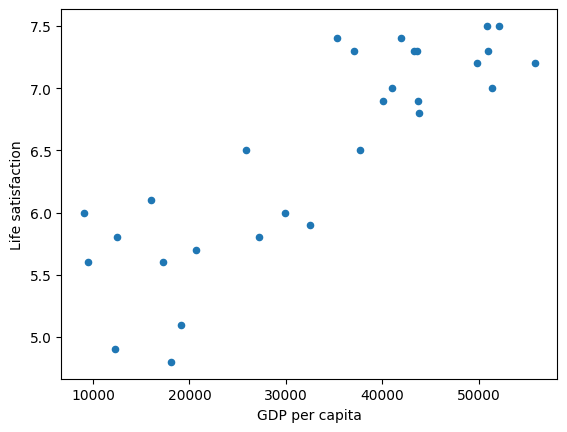

[[5.76666667]]


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model
import sklearn.neighbors

oecd_bli = pd.read_csv("/home/pedro/Documentos/Estudo/MachineLearning/handsOnML/oecd_bli_2015.csv", thousands=',')
gdp_per_capita = pd.read_csv("/home/pedro/Documentos/Estudo/MachineLearning/handsOnML/gdp_per_capita.csv", thousands=',', delimiter='\t', encoding='latin1', na_values="n/a")


country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

country_stats.plot(kind='scatter', x="GDP per capita", y='Life satisfaction')
plt.show()

# select a linear model
# model = sklearn.linear_model.LinearRegression()
model = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)
# train the model
model.fit(X, y)
# make a prediction for Cyprus
X_new = [[22587]]  # Cyprus' GDP per capita
print(model.predict(X_new))  # outputs [[5.96242338]]